<a href="https://colab.research.google.com/github/aibls/bishkek-resilience-ai/blob/main/bishkek_resilience_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 8.0 MB/s eta 0:00:00


In [2]:
!pip install pandas geopandas matplotlib

In [3]:
import osmnx as ox

In [4]:
import pandas as pd

In [5]:
import matplotlib.pyplot as plt

In [6]:
place = "Bishkek, Kyrgyzstan"

In [10]:
tags = {'amenity': 'school', 'man_made': 'tower', 'tower:type': 'communication'}

In [11]:
print("🛰️ Downloading Bishkek infrastructure...")
gdf = ox.features_from_place(place, tags)

🛰️ Downloading Bishkek infrastructure...


In [12]:
gdf_points = gdf[gdf.geometry.type == 'Point']

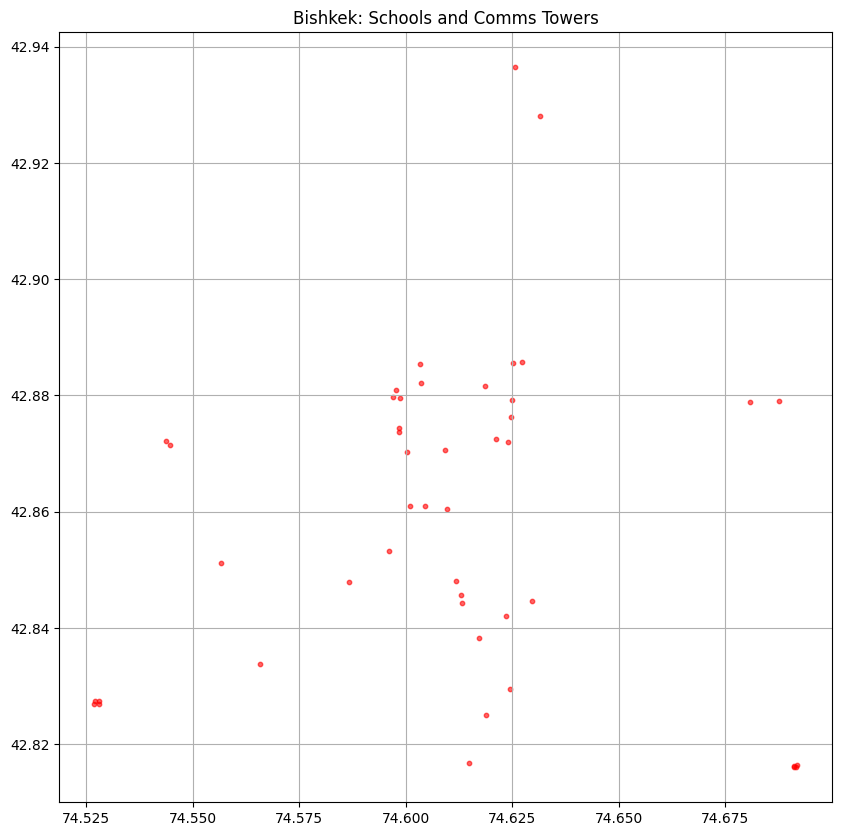

In [13]:
gdf_points.plot(figsize=(10, 10), markersize=10, color='red', alpha=0.6)
plt.title("Bishkek: Schools and Comms Towers")
plt.grid(True)
plt.show()

In [14]:
gdf_points.to_file("bishkek_nodes.geojson", driver='GeoJSON')
print("📂 File 'bishkek_nodes.geojson' is ready in your Colab file folder (left sidebar).")

📂 File 'bishkek_nodes.geojson' is ready in your Colab file folder (left sidebar).


In [15]:
# use folium to visualize the points on a map

In [16]:
import folium

In [22]:
bishkek_map = folium.Map(location = [42.882004, 74.582748], zoom_start = 12, tiles="CartoDB positron")

In [23]:
bishkek_map

In [26]:
# or I will try with gdf.explore() - function in GeoPandas, which handles automatically a folium setup

In [29]:
gdf.explore(tiles = "CartoDB positron", column = 'amenity', cmap = "Set1")

In [30]:
# the communication towers and schools are not separated. I want them to be visually separated.

In [31]:
gdf

geometry  \
element id                                                              
node    1408267731                          POINT (74.61169 42.84804)   
        1713077244                          POINT (74.62486 42.87923)   
        1915616212                          POINT (74.55652 42.85122)   
        2384947690                          POINT (74.62723 42.88573)   
        2384947691                           POINT (74.6252 42.88554)   
...                                                               ...   
way     1499865886  POLYGON ((74.63013 42.8179, 74.63146 42.81702,...   
        1499869388  POLYGON ((74.6264 42.84083, 74.62637 42.84032,...   
        1499874476  POLYGON ((74.60965 42.83479, 74.60989 42.83477...   
        1499874792  POLYGON ((74.61035 42.83175, 74.61025 42.83095...   
        1500159097  POLYGON ((74.62521 42.82084, 74.62571 42.8213,...   

                   man_made                                   name  \
element id                                                           
node    1408267731    tower                         Мачта РПО РМТР   
        1713077244    tower                                    NaN   
        1915616212      NaN                                    NaN   
        2384947690    tower                                    NaN   
        2384947691    tower                                    NaN   
...                     ...                                    ...   
way     1499865886      NaN  Школа-гимназия №63 им. Ч.Т. Айтматова   
        1499869388      NaN                     Школа-гимназия №26   
        1499874476      NaN                     Школа-гимназия №64   
        1499874792      NaN       Келечек Образовательный комплекс   
        1500159097      NaN                              Лицей КЭУ   

                     tower:type amenity addr:housenumber addr:street  \
element id                                                             
node    1408267731          NaN     NaN              NaN         NaN   
        1713077244  observation     NaN              NaN         NaN   
        1915616212          NaN  school              NaN         NaN   
        2384947690          NaN     NaN              NaN         NaN   
        2384947691          NaN     NaN              NaN         NaN   
...                         ...     ...              ...         ...   
way     1499865886          NaN  school              9/1         NaN   
        1499869388          NaN  school              NaN         NaN   
        1499874476          NaN  school             19/1         NaN   
        1499874792          NaN  school               39         NaN   
        1500159097          NaN  school              NaN         NaN   

                   communication:television tower:construction      name:ky  \
element id                                                                    
node    1408267731                      NaN                NaN          NaN   
        1713077244                      NaN                NaN          NaN   
        1915616212                      NaN                NaN          NaN   
        2384947690                      NaN                NaN          NaN   
        2384947691                      NaN                NaN          NaN   
...                                     ...                ...          ...   
way     1499865886                      NaN                NaN  №63 мектеби   
        1499869388                      NaN                NaN  №26 мектеби   
        1499874476                      NaN                NaN  №64 мектеби   
        1499874792                      NaN                NaN          NaN   
        1500159097                      NaN                NaN          NaN   

                    ... contact:whatsapp contact:youtube facebook image  \
element id          ...                                                   
node    1408267731  ...              NaN             NaN      NaN   NaN   
        17

In [40]:
print(gdf[['amenity', 'man_made', 'tower:type']].head())

                   amenity man_made   tower:type
element id                                      
node    1408267731     NaN    tower          NaN
        1713077244     NaN    tower  observation
        1915616212  school      NaN          NaN
        2384947690     NaN    tower          NaN
        2384947691     NaN    tower          NaN


In [41]:
gdf['tower:type'].unique()

array([nan, 'observation', 'communication', 'lighting', 'minaret'],
      dtype=object)

In [42]:
# I only need 'communication' type of towers, that's why I need to create a new gdf variable

In [49]:
gdf_new = gdf[(gdf['amenity'] == 'school') | (gdf['tower:type'] =='communication')]

In [50]:
gdf_new

geometry  \
element id                                                              
node    1915616212                          POINT (74.55652 42.85122)   
        2561105876                          POINT (74.62121 42.87254)   
        3643528413                          POINT (74.60917 42.87068)   
        3949236997                          POINT (74.68089 42.87882)   
        4045976978                          POINT (74.63147 42.92816)   
...                                                               ...   
way     1499865886  POLYGON ((74.63013 42.8179, 74.63146 42.81702,...   
        1499869388  POLYGON ((74.6264 42.84083, 74.62637 42.84032,...   
        1499874476  POLYGON ((74.60965 42.83479, 74.60989 42.83477...   
        1499874792  POLYGON ((74.61035 42.83175, 74.61025 42.83095...   
        1500159097  POLYGON ((74.62521 42.82084, 74.62571 42.8213,...   

                   man_made                                   name tower:type  \
element id                                                                      
node    1915616212      NaN                                    NaN        NaN   
        2561105876      NaN            Начальная школа Алтын-Башат        NaN   
        3643528413      NaN                  Школа Маленький Гений        NaN   
        3949236997      NaN                         Турецкий лицей        NaN   
        4045976978      NaN                                    NaN        NaN   
...                     ...                                    ...        ...   
way     1499865886      NaN  Школа-гимназия №63 им. Ч.Т. Айтматова        NaN   
        1499869388      NaN                     Школа-гимназия №26        NaN   
        1499874476      NaN                     Школа-гимназия №64        NaN   
        1499874792      NaN       Келечек Образовательный комплекс        NaN   
        1500159097      NaN                              Лицей КЭУ        NaN   

                   amenity addr:housenumber   addr:street  \
element id                                                  
node    1915616212  school              NaN           NaN   
        2561105876  school              107  Гоголя улица   
        3643528413  school              NaN           NaN   
        3949236997  school              NaN           NaN   
        4045976978  school              NaN           NaN   
...                    ...              ...           ...   
way     1499865886  school              9/1           NaN   
        1499869388  school              NaN           NaN   
        1499874476  school             19/1           NaN   
        1499874792  school               39           NaN   
        1500159097  school              NaN           NaN   

                   communication:television tower:construction      name:ky  \
element id                                                                    
node    1915616212                      NaN                NaN          NaN   
        2561105876                      NaN                NaN          NaN   
        3643528413                      NaN                NaN          NaN   
        3949236997                      NaN                NaN  Түрк лицейи   
        4045976978                      NaN                NaN          NaN   
...                                     ...                ...          ...   
way     1499865886                      NaN                NaN  №63 мектеби   
        1499869388                      NaN                NaN  №26 мектеби   
        1499874476                      NaN                NaN  №64 мектеби   
        1499874792                      NaN                NaN          NaN   
        1500159097                      NaN                NaN          NaN   

                    ... contact:whatsapp contact:youtube facebook image  \
element id          ...                                                   
node    1915616212  ...              NaN             NaN      NaN   NaN   
        25

In [51]:
gdf_new['tower:type'].unique()

array([nan, 'communication'], dtype=object)

In [53]:
gdf_new.explore(tiles = 'CartoDB positron')

In [ ]:
# The problem: Some towers are unlabeled which makes it difficult to understand whether they are for communication or they are for other stuff. And

#### The problem: Some towers are unlabeled which makes it difficult to understand whether they are for communication or they are for other stuff. And the other problem is that both schools and towers are represented in one color which makes it difficult to actually see the difference on the map

In [58]:
gdf_new['category'] = 'Unknown Tower'

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [63]:
gdf_new.loc[gdf_new['amenity'] == 'school', 'category'] = 'School'

In [64]:
gdf_new.loc[gdf_new['tower:type'] == 'communication', 'category'] = 'Communication Tower'

In [65]:
gdf_new

,geometry,man_made,name,tower:type,amenity,addr:housenumber,addr:street,communication:television,tower:construction,name:ky,...,contact:youtube,facebook,image,religion,sorting_name,strapline,start_date,type,addr:housenumber:en,category
"(node, 1915616212)",POINT (74.55652 42.8512172),NaN,NaN,NaN,school,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,School
"(node, 2561105876)",POINT (74.6212078 42.8725357),NaN,Начальная школа Алтын-Башат,NaN,school,107,Гоголя улица,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,School
"(node, 3643528413)",POINT (74.6091651 42.8706795),NaN,Школа Маленький Гений,NaN,school,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,School
"(node, 3949236997)",POINT (74.6808905 42.8788159),NaN,Турецкий лицей,NaN,school,NaN,NaN,NaN,NaN,Түрк лицейи,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,School
"(node, 4045976978)",POINT (74.6314711 42.9281635),NaN,NaN,NaN,school,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,School
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(way, 1499869388)","POLYGON ((74.6263996 42.8408321, 74.6263664 42...",NaN,Школа-гимназия №26,NaN,school,NaN,NaN,NaN,NaN,№26 мектеби,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,School
"(way, 1499874476)","POLYGON ((74.6096477 42.8347852, 74.6098861 42...",NaN,Школа-гимназия №64,NaN,school,19/1,NaN,NaN,NaN,№64 мектеби,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,School
"(way, 1499874792)","POLYGON ((74.6103465 42.8317533, 74.6102531 42...",NaN,Келечек Образовательный комплекс,NaN,school,39,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,School
"(way, 1500159097)","POLYGON ((74.6252144 42.8208395, 74.6257078 42...",NaN,Лицей КЭУ,NaN,school,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,School


In [68]:
gdf_new = gdf_new.drop('category', axis=0)

In [69]:
gdf_new.tail()

,geometry,man_made,name,tower:type,amenity,addr:housenumber,addr:street,communication:television,tower:construction,name:ky,...,contact:youtube,facebook,image,religion,sorting_name,strapline,start_date,type,addr:housenumber:en,category
"(way, 1499865886)","POLYGON ((74.63013 42.8179, 74.63146 42.81702,...",NaN,Школа-гимназия №63 им. Ч.Т. Айтматова,NaN,school,9/1,NaN,NaN,NaN,№63 мектеби,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,School
"(way, 1499869388)","POLYGON ((74.6264 42.84083, 74.62637 42.84032,...",NaN,Школа-гимназия №26,NaN,school,NaN,NaN,NaN,NaN,№26 мектеби,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,School
"(way, 1499874476)","POLYGON ((74.60965 42.83479, 74.60989 42.83477...",NaN,Школа-гимназия №64,NaN,school,19/1,NaN,NaN,NaN,№64 мектеби,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,School
"(way, 1499874792)","POLYGON ((74.61035 42.83175, 74.61025 42.83095...",NaN,Келечек Образовательный комплекс,NaN,school,39,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,School
"(way, 1500159097)","POLYGON ((74.62521 42.82084, 74.62571 42.8213,...",NaN,Лицей КЭУ,NaN,school,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,School


In [72]:
gdf_new['category'].unique()

array(['School', 'Communication Tower'], dtype=object)

In [73]:
gdf_labeled = gdf.copy()

In [76]:
gdf_labeled['category'] = 'Unknown Tower'

In [77]:
gdf_labeled

geometry  \
element id                                                              
node    1408267731                          POINT (74.61169 42.84804)   
        1713077244                          POINT (74.62486 42.87923)   
        1915616212                          POINT (74.55652 42.85122)   
        2384947690                          POINT (74.62723 42.88573)   
        2384947691                           POINT (74.6252 42.88554)   
...                                                               ...   
way     1499865886  POLYGON ((74.63013 42.8179, 74.63146 42.81702,...   
        1499869388  POLYGON ((74.6264 42.84083, 74.62637 42.84032,...   
        1499874476  POLYGON ((74.60965 42.83479, 74.60989 42.83477...   
        1499874792  POLYGON ((74.61035 42.83175, 74.61025 42.83095...   
        1500159097  POLYGON ((74.62521 42.82084, 74.62571 42.8213,...   

                   man_made                                   name  \
element id                                                           
node    1408267731    tower                         Мачта РПО РМТР   
        1713077244    tower                                    NaN   
        1915616212      NaN                                    NaN   
        2384947690    tower                                    NaN   
        2384947691    tower                                    NaN   
...                     ...                                    ...   
way     1499865886      NaN  Школа-гимназия №63 им. Ч.Т. Айтматова   
        1499869388      NaN                     Школа-гимназия №26   
        1499874476      NaN                     Школа-гимназия №64   
        1499874792      NaN       Келечек Образовательный комплекс   
        1500159097      NaN                              Лицей КЭУ   

                     tower:type amenity addr:housenumber addr:street  \
element id                                                             
node    1408267731          NaN     NaN              NaN         NaN   
        1713077244  observation     NaN              NaN         NaN   
        1915616212          NaN  school              NaN         NaN   
        2384947690          NaN     NaN              NaN         NaN   
        2384947691          NaN     NaN              NaN         NaN   
...                         ...     ...              ...         ...   
way     1499865886          NaN  school              9/1         NaN   
        1499869388          NaN  school              NaN         NaN   
        1499874476          NaN  school             19/1         NaN   
        1499874792          NaN  school               39         NaN   
        1500159097          NaN  school              NaN         NaN   

                   communication:television tower:construction      name:ky  \
element id                                                                    
node    1408267731                      NaN                NaN          NaN   
        1713077244                      NaN                NaN          NaN   
        1915616212                      NaN                NaN          NaN   
        2384947690                      NaN                NaN          NaN   
        2384947691                      NaN                NaN          NaN   
...                                     ...                ...          ...   
way     1499865886                      NaN                NaN  №63 мектеби   
        1499869388                      NaN                NaN  №26 мектеби   
        1499874476                      NaN                NaN  №64 мектеби   
        1499874792                      NaN                NaN          NaN   
        1500159097                      NaN                NaN          NaN   

                    ... contact:youtube facebook image religion sorting_name  \
element id          ...                                                        
node    1408267731  ...             NaN      NaN   NaN      NaN          Na

In [80]:
gdf_labeled.loc[gdf['amenity'] == 'school', 'category'] = 'School'

In [83]:
gdf_labeled.loc[gdf['tower:type'] == 'communication', 'category'] = 'Communication Tower'

In [85]:
gdf_labeled['category'].unique()

array(['Unknown Tower', 'School', 'Communication Tower'], dtype=object)

In [88]:
gdf_labeled.explore(column = 'category', tiles = 'CartoDB positron', cmap=['blue', 'red', 'gray'])